<a href="https://colab.research.google.com/github/Korobokkk/Kiselev_I_dsp-seminars/blob/kiselev_second_lab/seminars/2_Kiselev.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Практическое задание №2
## Амплитудная и фазовая модуляция: генерация, спектры, демодуляция и устойчивость к шумам

**Цель работы:**
- Научиться генерировать сигналы с амплитудной (АМ) и фазовой (ФМ) модуляцией.
- Исследовать спектральные характеристики модулированных сигналов.
- Изучить влияние индекса модуляции на спектр ФМ сигнала.
- Освоить демодуляцию АМ и ФМ с помощью преобразования Гильберта.
- Оценить устойчивость АМ и ФМ к амплитудному шуму на примере реального аудиосигнала.

**Необходимое ПО:** Python 3, библиотеки `numpy`, `matplotlib`, `scipy`, `ipywidgets`, `IPython.display`. Работа выполняется в Jupyter Notebook / Google Colab.

**Формат сдачи:** один Jupyter Notebook с кодом, графиками и текстовыми выводами. Имя файла: `2_Фамилия.ipynb`.

## Часть 1. Генерация и визуализация модулированных сигналов

### 1.1. Импорт библиотек и параметры

In [452]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.io import wavfile
from scipy.signal import hilbert
import ipywidgets as widgets
from IPython.display import Audio, display

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 5)

# Параметры дискретизации для демонстрации
fs = 10000                     # частота дискретизации (Гц)
T = 0.1                        # длительность сигнала (с)
t = np.linspace(0, T, int(fs*T), endpoint=False)

# Несущая
fc = 1000                      # частота несущей (Гц)
Ac = 1.0                       # амплитуда несущей

### 1.2. Модулирующий сигнал

В качестве модулирующего сигнала используйте сумму двух синусоид с частотами 100 Гц и 150 Гц, нормализованную к диапазону [-1, 1]. Постройте его график.

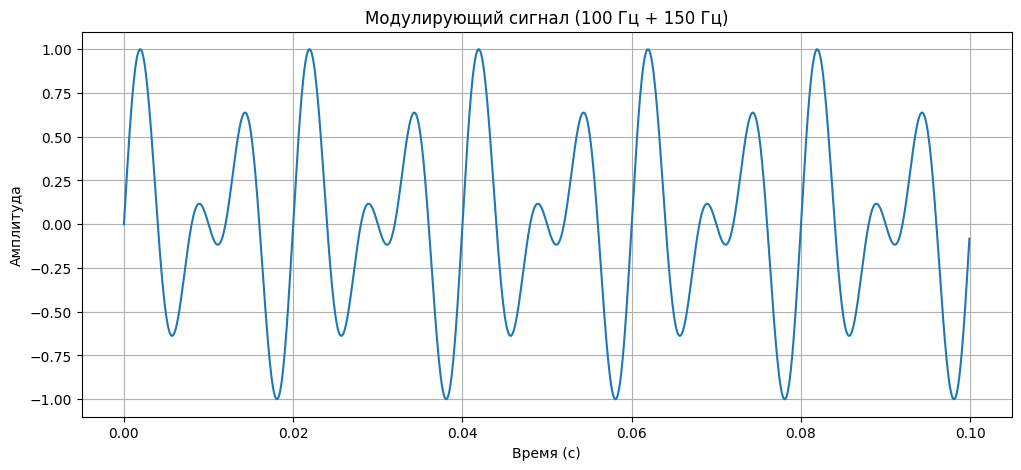

In [453]:
fm1 = 100
fm2 = 150
m_t =  Ac * np.sin(2 * np.pi * fm1 * t ) + Ac * np.sin(2 * np.pi * fm2 * t )
m_t = m_t / np.max(np.abs(m_t))
plt.figure()
plt.plot(t, m_t)
plt.title('Модулирующий сигнал (100 Гц + 150 Гц)')
plt.xlabel('Время (с)')
plt.ylabel('Амплитуда')
plt.grid(True)
plt.show()

### 1.3. Амплитудная модуляция (АМ)

Формула АМ:
$$s_{AM}(t) = A_c [1 + a_{AM}\cdot m(t)] \cos(2\pi f_c t)
$$
Параметр $a_{AM}$ регулирует _глубину модуляции_, он не может быть больше 1 (при $a_{AM}>1$ и исходном сигнале $m(t)$, нормализованном на единицу, амплитуда результирующего сигнала в некоторые промежутки времени становится отрицательной).

In [454]:
a_am = 0.2
s_am = Ac * (1 + a_am * m_t) * np.cos(2*np.pi*fc*t)

### 1.4. Фазовая модуляция (ФМ)

Формула ФМ:
$$
s_{PM}(t) = A_c \cos(2\pi f_c t + \beta \cdot m(t)),
$$

где $\beta$ – индекс фазовой модуляции.

In [455]:
beta_pm = 5
s_pm = Ac * np.cos(2*np.pi*fc*t + beta_pm * m_t)

Постройте на одном графике модулирующий сигнал и оба модулированных сигнала (АМ, ФМ). Оси и графики должны быть подписаны.

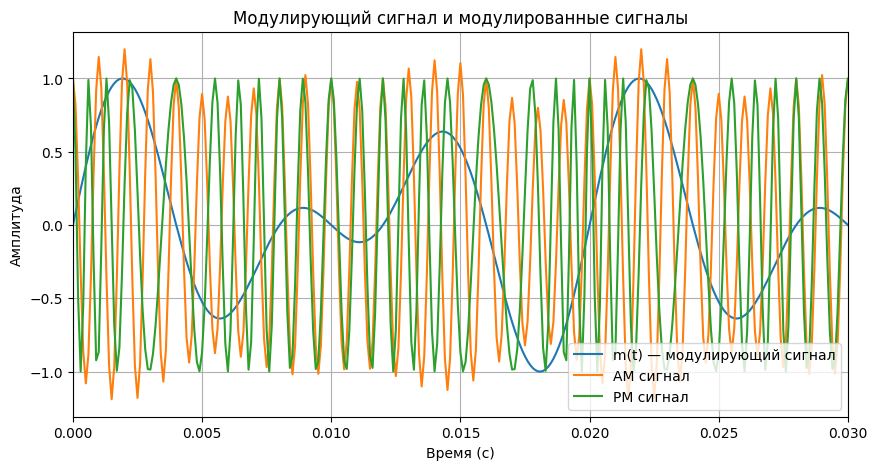

In [456]:
plt.figure(figsize=(10, 5))

plt.plot(t, m_t,  label='m(t) — модулирующий сигнал')
plt.plot(t, s_am, label='AM сигнал')
plt.plot(t, s_pm,  label='PM сигнал')

plt.title('Модулирующий сигнал и модулированные сигналы')
plt.xlabel('Время (с)')
plt.ylabel('Амплитуда')

plt.legend(loc='lower right')
plt.grid(True)

plt.xlim(0, 0.03)

plt.show()

## Часть 2. Спектральный анализ модулированных сигналов

### 2.1. Функция построения амплитудного спектра
Реализуйте функцию построения амплитудного спектра ```plot_spectrum(s,fs,title)```
Значения аргументов:
* `s` - массив, содержащий значения сигнала
* `fs` - частота отсчётов сигнала
* `title` - заголовок графика, выводимый сверху

На графике по горизонтальной оси должна быть отложена частота в герцах, а по вертикальной - амплитуда гармоники. График должен строиться только для положительных значений частоты. Оси должны быть подписаны.

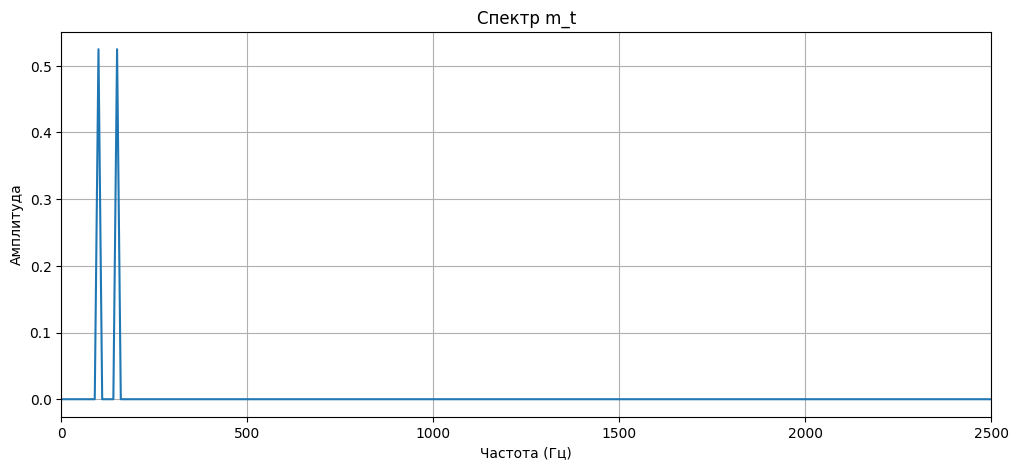

In [457]:
def plot_spectrum(s, fs, title):
  N = len(s)
  X = np.fft.fft(s)
  freq = np.fft.fftfreq(N, d=1/fs)

  half = N//2
  X_mag =  2* np.abs(X[:half]) / N
  freq_pos = freq[:half]

  plt.figure()
  plt.plot(freq_pos, X_mag)
  plt.title(title)
  plt.xlabel('Частота (Гц)')
  plt.ylabel('Амплитуда')
  plt.xlim(0, fs/4)
  plt.grid(True)
  plt.show()

plot_spectrum(m_t, fs, "Спектр m_t")

### 2.2. Спектр АМ

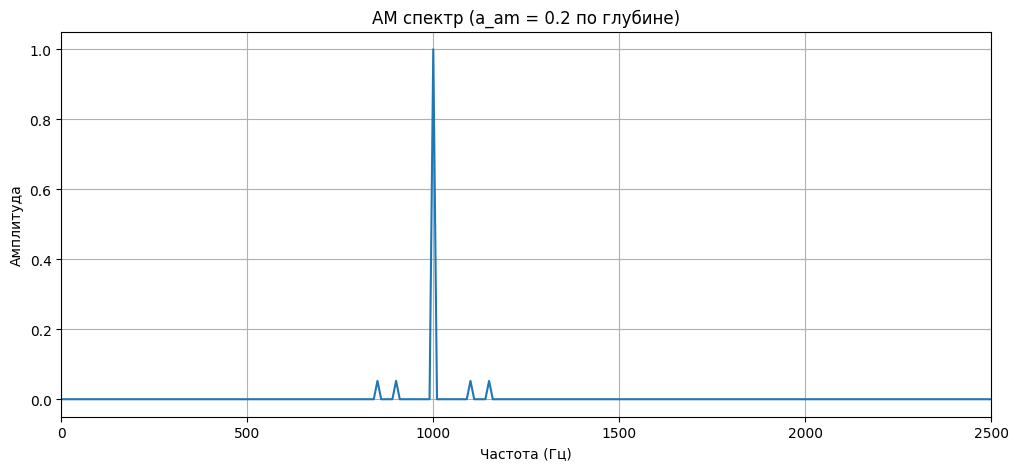

In [458]:
plot_spectrum(s_am, fs, f'АМ спектр (a_am = {a_am} по глубине)')

### 2.3. Спектр ФМ при разных индексах модуляции

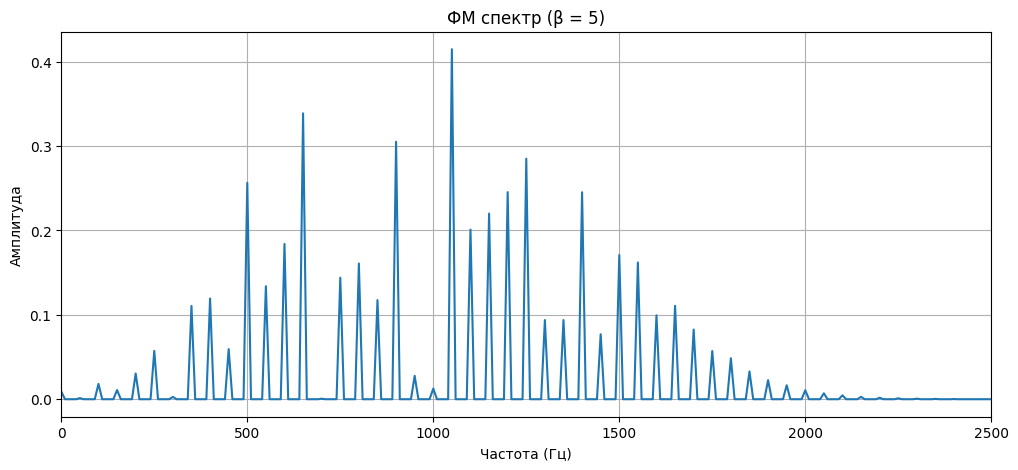

In [459]:
plot_spectrum(s_pm, fs, f'ФМ спектр (β = {beta_pm})')

Для ФМ постройте на одном графике спектры для разных индексов модуляции (например, β = 0.1, 0.3, 1, 2, 5, 10). Оси и графики должны быть подписаны.

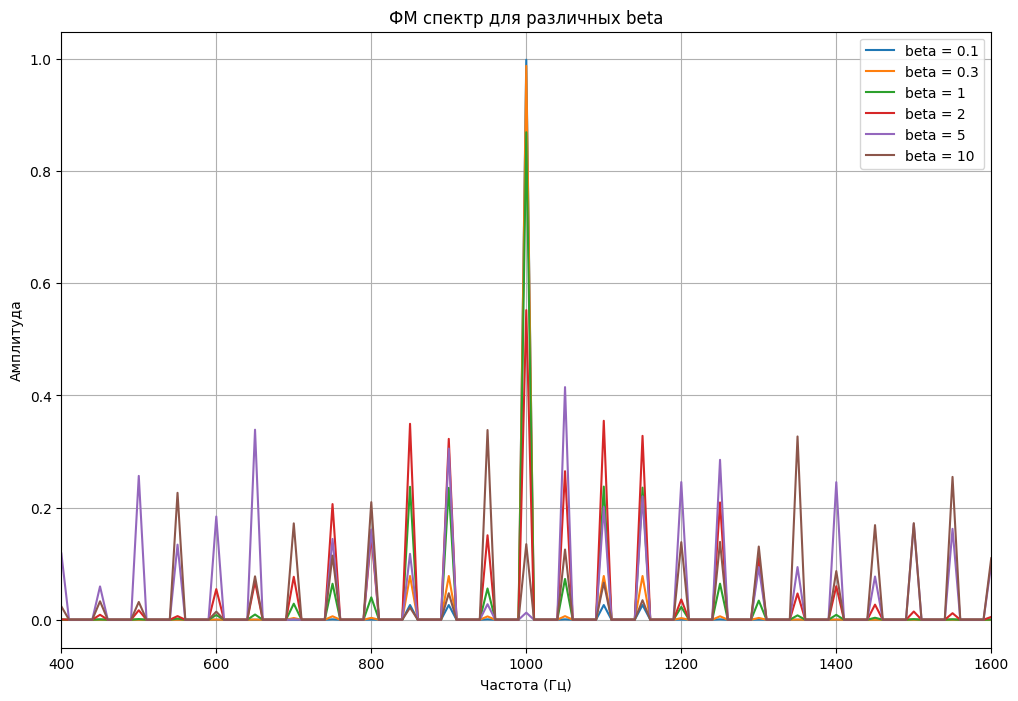

In [460]:
def make_superplt(beta_arr, signals, fs, fc, name_plt):
  plt.figure(figsize=(12,8))
  for beta in beta_arr:
    s_pm = 1 * np.cos(2*np.pi*fc*t + beta * signals)
    N = len(s_pm)
    X = np.fft.fft(s_pm)
    freq = np.fft.fftfreq(N, d=1/fs)

    half = N // 2
    X_mag = np.abs(X[:half]) / N
    X_mag[1:] *= 2

    freq_pos = freq[:half]

    plt.plot(freq_pos, X_mag,  label=f'beta = {beta}')

  plt.title(name_plt)
  plt.xlabel('Частота (Гц)')
  plt.ylabel('Амплитуда')
  plt.grid(True)
  plt.legend()

  plt.xlim(fc -600, fc +600)
  #plt.xlim(0,fs/4)

  plt.show()


beta_arr = [0.1, 0.3, 1, 2, 5, 10]
make_superplt(beta_arr, m_t, fs, fc, "ФМ спектр для различных beta")


### 2.4. Интерактивное исследование спектра ФМ
Создайте интерактивный график для исследования зависимости спектра ФМ-сигнала от индекса модуляции.

In [ ]:
from ipywidgets import interact, FloatSlider

def pm_spectrum(beta=5):
  s_pm = Ac * np.cos(2 * np.pi * fc * t + beta * m_t)
  plot_spectrum(s_pm, fs, f'ФМ спектр (β = {beta:.1f})')

widgets.interact(pm_spectrum, beta=widgets.FloatSlider(min=0.1, max=20, step=0.1, value=5));

**Вопросы:**
- Почему спектр АМ содержит только пять ярко выраженных компоненты (несущая и по две боковых с каждой стороны от неё)?
- Опишите, как выглядит спектр ФМ при малых β?
- Что происходит с амплитудой несущей и боковыми полосами ФМ при увеличении β?

1. Поскольку модулирующий сигнал состоит из двух синусоид (100 Гц и 150 Гц), в спектре появляются компоненты:
  несущая,
  боковые полосы: +-100 Гц от несущей,
  боковые полосы: +-150 Гц от несущей.


2. При малых значениях индекса модуляции β спектр ФМ-сигнала состоит в основном из несущей компоненты и ближайших к нему боковых полос

3. При увеличении β: расширяется спектр, увеличивается кол-во боковых амплитуд, уменьшается амплитуда несущей.

## Часть 3. Демодуляция сигналов

### 3.1. Демодуляция АМ с помощью преобразования Гильберта

Преобразование Гильберта позволяет получить аналитический сигнал, огибающая которого содержит исходное сообщение.

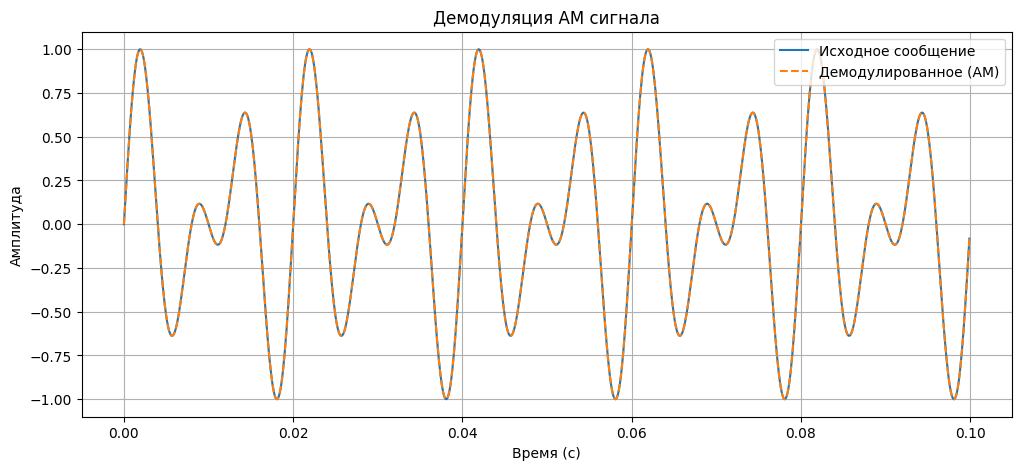

In [461]:
# Аналитический сигнал для АМ
analytic_am = hilbert(s_am)
envelope = np.abs(analytic_am) # огибающая = 1 + m(t)

# Убираем постоянную составляющую
demod_am = envelope/ Ac - 1

# Нормализуем сигнал
demod_am = demod_am/a_am

# Сравнение с исходным
plt.figure()
plt.plot(t, m_t, label='Исходное сообщение')
plt.plot(t, demod_am, '--', label='Демодулированное (АМ)')
plt.xlabel('Время (с)')
plt.ylabel('Амплитуда')
plt.title('Демодуляция АМ сигнала')
plt.legend()
plt.grid(True)
plt.show()

Вычислите среднеквадратичную ошибку между исходным и восстановленным сообщением с помощью функции `np.std`.

In [462]:
error = m_t - demod_am
mse = np.std(error**2)

print(f'СКО: {mse:.6f}')

СКО: 0.000000


### 3.2. Демодуляция ФМ сигнала

Для ФМ информация заключена в отклонении фазы от линейного тренда. Используем аналитический сигнал и выделим мгновенную фазу.

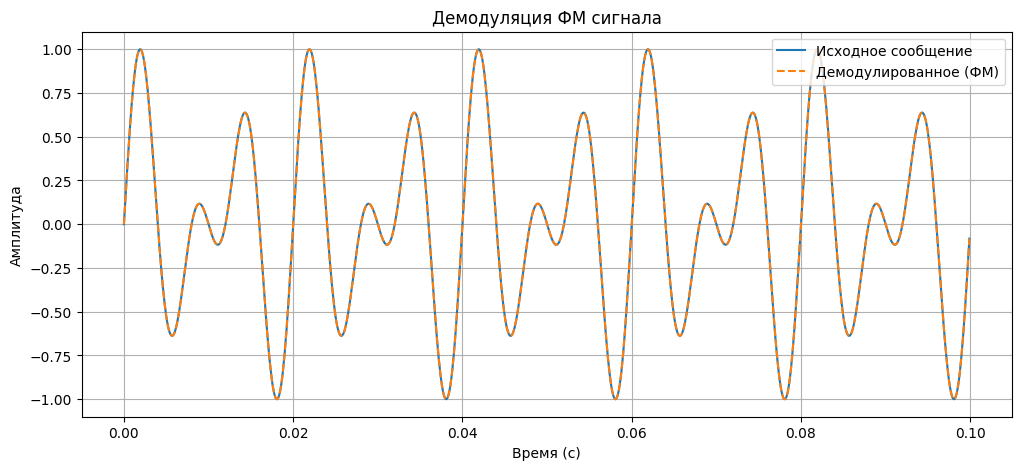

In [463]:
# Аналитический сигнал для ФМ
analytic_pm = hilbert(s_pm)
inst_phase = np.unwrap(np.angle(analytic_pm))   # развернутая фаза

# Убираем линейную составляющую (фаза несущей)
phase_no_carrier = inst_phase - 2 * np.pi * fc * t

# Убираем постоянную составляющую (может появиться в общем случае при наличии шумов, искажений и т. п.)
demod_pm = phase_no_carrier - np.mean(phase_no_carrier)

# Нормализуем сигнал
demod_pm = demod_pm / beta_pm

# Сравнение с исходным
plt.figure()
plt.plot(t, m_t, label='Исходное сообщение')
plt.plot(t, demod_pm, '--', label='Демодулированное (ФМ)')
plt.xlabel('Время (с)')
plt.ylabel('Амплитуда')
plt.title('Демодуляция ФМ сигнала')
plt.legend()
plt.grid(True)
plt.show()

**Вопрос:** Почему важно использовать `np.unwrap` для фазы?

Функция `np.unwrap` используется для устранения скачков фазы, возникающей в ф-ии `np.angle` из-за её представления в диапазоне [−π,π]. `unwrap` обеспечивает непрерывность фазы, необходимую для корректного выделения модулирующего сигнала.

## Часть 4. Устойчивость к шумам

В этой части мы работаем с реальным аудиофайлом. Для примера WAV-файл расположен в том же репозитории, что и ноутбук по адресу `data/sample-3s.wav`, но его надо загрузить в Google Colab.

### 4.1. Загрузка аудио (или генерация тестового сигнала)

In [464]:
# Загружаем файл и сохраняем под именем audio.wav
!wget -O audio.wav "https://github.com/korzhimanov/dsp-seminars/raw/refs/heads/main/data/sample-3s.wav"

--2026-03-29 18:41:47--  https://github.com/korzhimanov/dsp-seminars/raw/refs/heads/main/data/sample-3s.wav
Resolving github.com (github.com)... 140.82.112.3
Connecting to github.com (github.com)|140.82.112.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/korzhimanov/dsp-seminars/refs/heads/main/data/sample-3s.wav [following]
--2026-03-29 18:41:47--  https://raw.githubusercontent.com/korzhimanov/dsp-seminars/refs/heads/main/data/sample-3s.wav
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 563756 (551K) [audio/wav]
Saving to: ‘audio.wav’

audio.wav           100%[===================>] 550.54K  --.-KB/s    in 0.04s   

2026-03-29 18:41:47 (14.6 MB/s) - ‘audio.wav’ saved [563756/563756]



In [465]:
fs_audio, melody_stereo = wavfile.read('audio.wav') # читаем wav-файл в массив numpy, в файл записан стереосигнал, поэтому melody_stereo будет содержать две дорожки (левую и правую)

melody = melody_stereo[:,0] # переходим к моносигналу, беря только одну из двух дорожек
melody = melody / np.max(np.abs(melody)) # нормализуем сигнал, чтобы корректно работала амплитудная модуляция

t_audio = np.linspace(0, melody.shape[0]/fs_audio, melody.shape[0], endpoint=False) # для визуализации создаём также массив временных отсчётов

print(f"Частота дискретизации: {fs_audio} Гц")
print(f"Длина временного ряда: {len(melody)}")
print(f"Тип данных: {melody.dtype}")

print("Исходное аудио:")
display(Audio(melody, rate=fs_audio))

Частота дискретизации: 44100 Гц
Длина временного ряда: 140928
Тип данных: float64
Исходное аудио:


Постройте графики самого сигнала и его спектра. Подпишите оси.

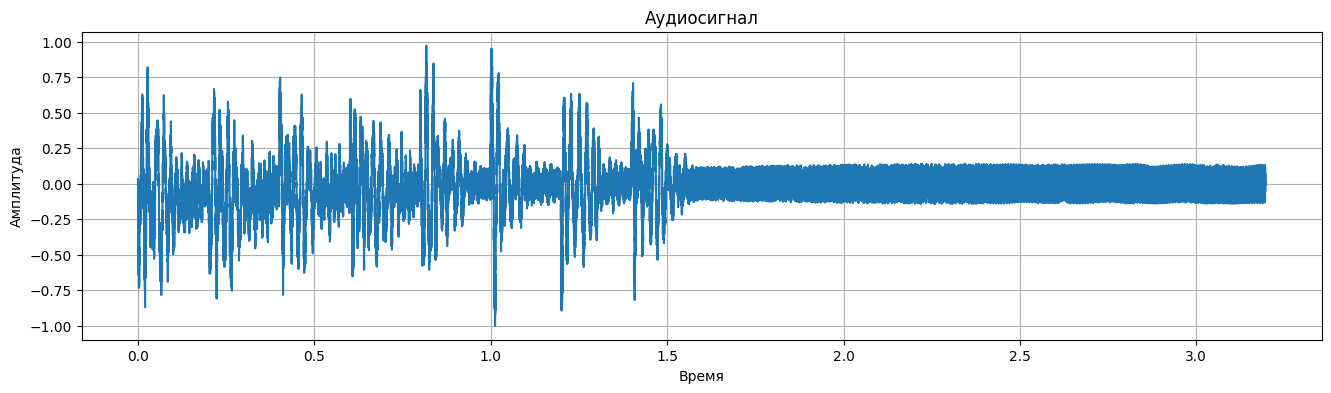

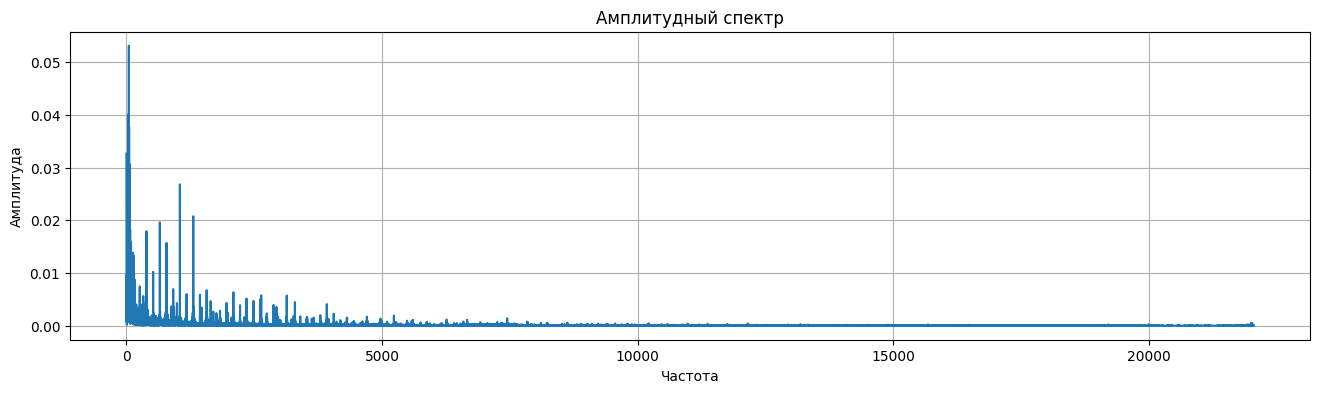

In [466]:
plt.figure(figsize=(16, 4))
plt.plot(t_audio, melody)
plt.title('Аудиосигнал')
plt.xlabel('Время')
plt.ylabel('Амплитуда')
plt.grid(True)

plt.show()

N = len(melody)
X = np.fft.fft(melody)
freq = np.fft.fftfreq(N, d=1/fs_audio)

half = N//2
X_mag =  2* np.abs(X[:half]) / N
freq_pos = freq[:half]

plt.figure(figsize=(16, 4))
plt.plot(freq_pos, X_mag)
plt.title('Амплитудный спектр')
plt.xlabel('Частота')
plt.ylabel('Амплитуда')
# plt.xlim(0, 20)
plt.grid(True)
plt.show()

**Вопрос:** До каких частот наблюдаются заметные пики в сигнале? Подумайте, какую частоту несущей можно выбрать при частоте дискретизации 44,1 кГц, чтобы эти пики не потерять. Как на это влияет выбор индекса модуляции ФМ-сигнала?

Заметные пики в спектре наблюдаются примерно до 3–4 кГц, что соответствует основной полосе аудиосигнала.

При частоте дискретизации 44.1 кГц максимальная допустимая частота по теореме Найквиста составляет 22.05 кГц, поэтому несущую следует выбирать с запасом выше полосы сигнала, но в пределах максимально допустимого спектра (Например 10-15 Гц.)

При фазовой модуляции ширина спектра увеличивается с ростом индекса модуляции β (по правилу Карсона).
Поэтому при слишком больших значениях β спектр может выйти за пределы Найквиста, что приведёт к алиасингу. Это ограничивает допустимое значение β.

### 4.2. Подготовка к модуляции (интерполяция)

Выберите частоту несущей в соответствии с ответом на предыдущий вопрос (если восстановленный сигнал будет сильно зашумлён, попробуйте другие значения).

In [467]:
fc_high = 5000 # несущая 5 кГц
Ac = 1

### 4.3. Модуляция аудиосигнала
Сгенерируйте модулированные сигналы. Индекс модуляции для ФМ-сигнала выберите так, чтобы несильно портить модулируемый сигнал.

In [468]:
# АМ
a_am = 0.2
s_am_audio = Ac * (1 + a_am * melody) * np.cos(2 * np.pi * fc_high * t_audio)

# ФМ
beta_pm_audio = 2
s_pm_audio = Ac * np.cos(2 * np.pi * fc_high * t_audio + beta_pm_audio * melody)

### 4.4. Добавление шумов

**Амплитудный шум:** мультипликативный гауссов шум.

In [469]:
noise_amp = 0.1 * np.random.randn(len(t_audio))
s_am_noisy = s_am_audio * (1 + noise_amp)
s_pm_noisy = s_pm_audio * (1 + noise_amp)

### 4.5. Демодуляция сигналов

**Демодуляция АМ:**

Используйте преобразование Гильберта, чтобы демодулировать АМ-сигнал без шума, убедитесь, что качество звука изменилось незначительно.

СКО: 0.005636


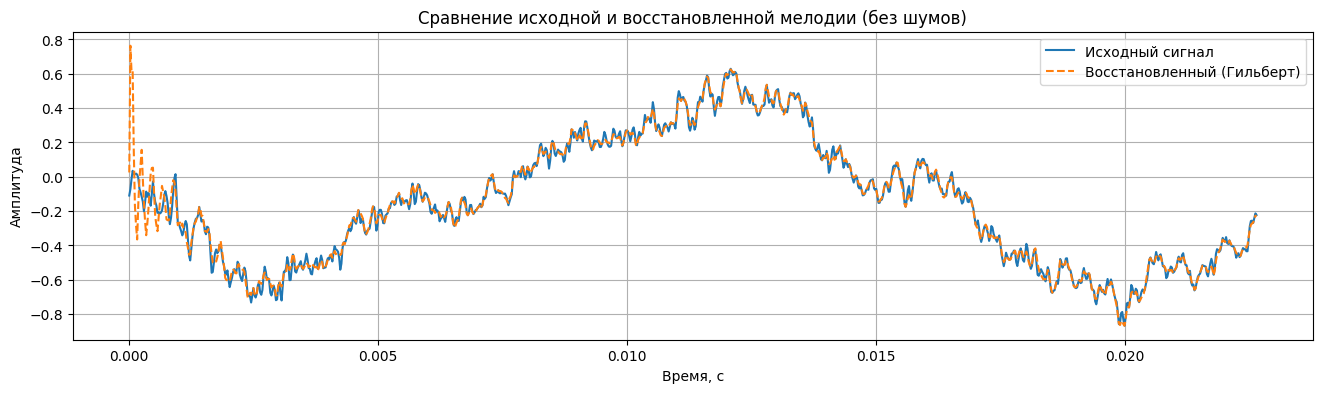

In [470]:
envelope = np.abs(hilbert(s_am_audio))
m_recovered = (envelope / Ac - 1)/a_am

# error check
error = melody - m_recovered
mse = np.std(error**2)

print(f'СКО: {mse:.6f}')

plt.figure(figsize=(16, 4))
plt.plot(t_audio[:1000], melody[:1000], label='Исходный сигнал')
plt.plot(t_audio[:1000], m_recovered[:1000], '--', label='Восстановленный (Гильберт)')
plt.legend()
plt.title('Сравнение исходной и восстановленной мелодии (без шумов)')
plt.xlabel('Время, с')
plt.ylabel('Амплитуда')
plt.grid(True)
plt.show()

Демодулируйте зашумлёный АМ-сигнал.

СКО: 0.005636


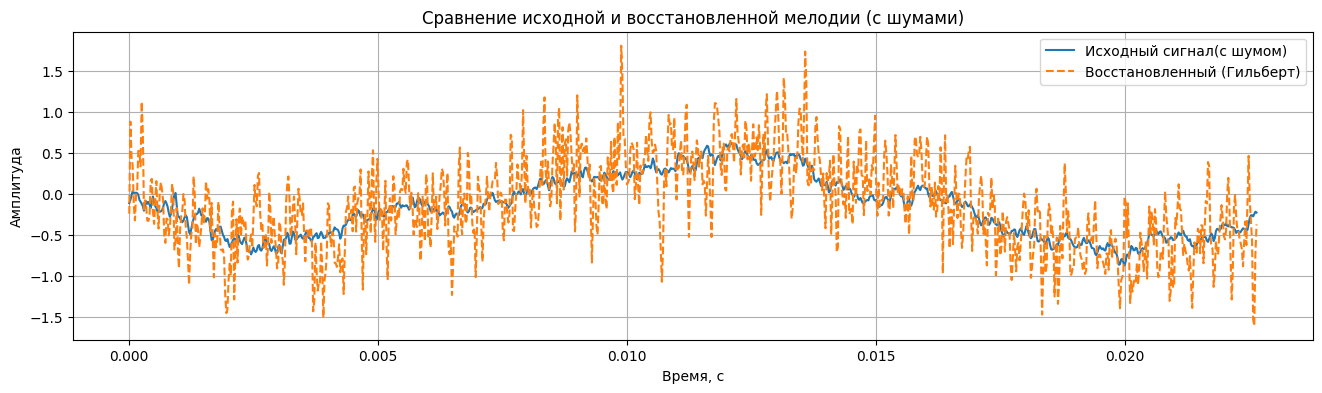

In [471]:
envelope = np.abs(hilbert(s_am_noisy))
m_recovered2 = (envelope / Ac - 1)/a_am

# error check
error = melody - m_recovered
mse = np.std(error**2)

print(f'СКО: {mse:.6f}')

plt.figure(figsize=(16, 4))
plt.plot(t_audio[:1000], melody[:1000], label='Исходный сигнал(с шумом)')
plt.plot(t_audio[:1000], m_recovered2[:1000], '--', label='Восстановленный (Гильберт)')
plt.legend()
plt.title('Сравнение исходной и восстановленной мелодии (с шумами)')
plt.xlabel('Время, с')
plt.ylabel('Амплитуда')
plt.grid(True)
plt.show()

Тест звука:

In [472]:
display(Audio(melody, rate=fs_audio))

display(Audio(m_recovered, rate=fs_audio))

display(Audio(m_recovered2, rate=fs_audio))

**Вопросы:**
* Изменилось ли качество звука?
* Зафиксируйте $a_{AM}=0{,}2$. Попробуйте поменять амплитуду шума. При каких значениях амплитуды вы слышите заметную разницу с оригиналом?
* Зафиксируйте амплитуду шума равную 0,01. Попробуйте поменять $a_{AM}$, при каких амплитудах модуляции начинаются заметные искажения? Сделайте вывод о соотношении $a_{AM}$ и допустимых уровнях шума.

1. Качество звука очевидно изменилось. При восстановлении сигнала без помех качество звука изменяется незначительно. При наличии шума, количесво помех значительно увеличивается, что заметно даже при амплитуде  0.03 - 0.05.

2. Смотря что имеется ввиду под 'заметной разницей'. К примеру, при величине амплитуды шума = 0.1 помехи 'вытесняют'(не дают распознать) исходный звук. При амплитуде шума 0.05 качество звука меняется, однако исхрдный сигнал вполне уловим. При амплитуде шума 0.01 помехи заметны но незначительны.

3. При фиксированной амплитуде звука(0.01) рассмотрим разные a. При а=0.1 помехи сильнозаметные. при а в пределах (0.2, 0.4) помехи слабозаметны  При увеличении a до 0.05 качество получаемого на выходе звука увеличивается и искажения почти незаметны. Очевидно, что чем меньше а, тем выше шумоустойчивость.

**Демодуляция ФМ:**

Используйте метод аналитического сигнала для демодуляции ФМ-сигнала. Убедитесь, что качество звука изменилось незначительно.

MSE: 0.000083


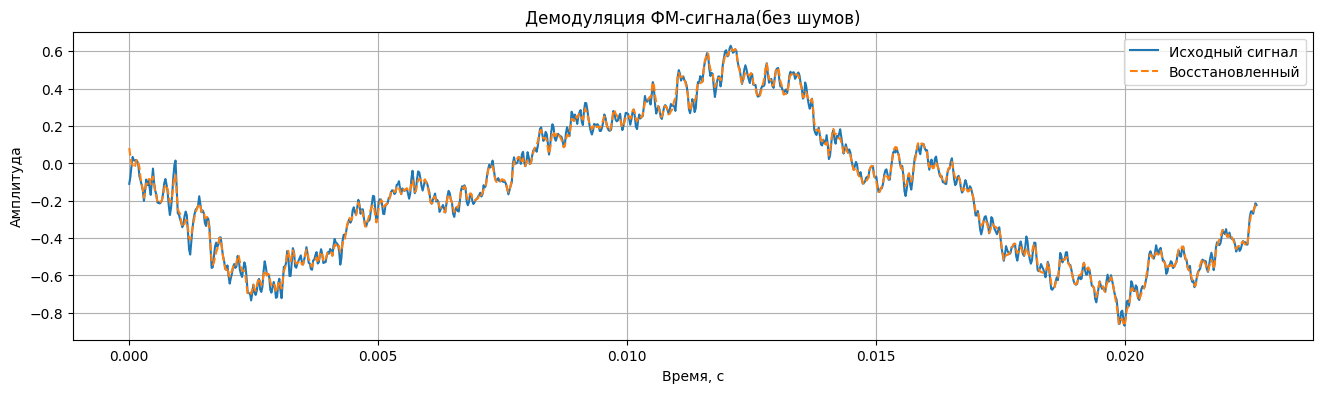

In [473]:
analytic = hilbert(s_pm_audio)
instant_phase = np.unwrap(np.angle(analytic))
carrier_phase = 2 * np.pi * fc_high * t_audio
melody_restored = (instant_phase - carrier_phase) / beta_pm_audio

# error check
mse = np.mean((melody - melody_restored)**2)
print(f'MSE: {mse:.6f}')

plt.figure(figsize=(16, 4))
plt.plot(t_audio[:1000], melody[:1000], label='Исходный сигнал')
plt.plot(t_audio[:1000], melody_restored[:1000], '--', label='Восстановленный')
plt.legend()
plt.title('Демодуляция ФМ-сигнала(без шумов)')
plt.xlabel('Время, с')
plt.ylabel('Амплитуда')
plt.grid(True)
plt.show()

Демодулируйте зашумлёный ФМ-сигнал.

MSE: 0.001053


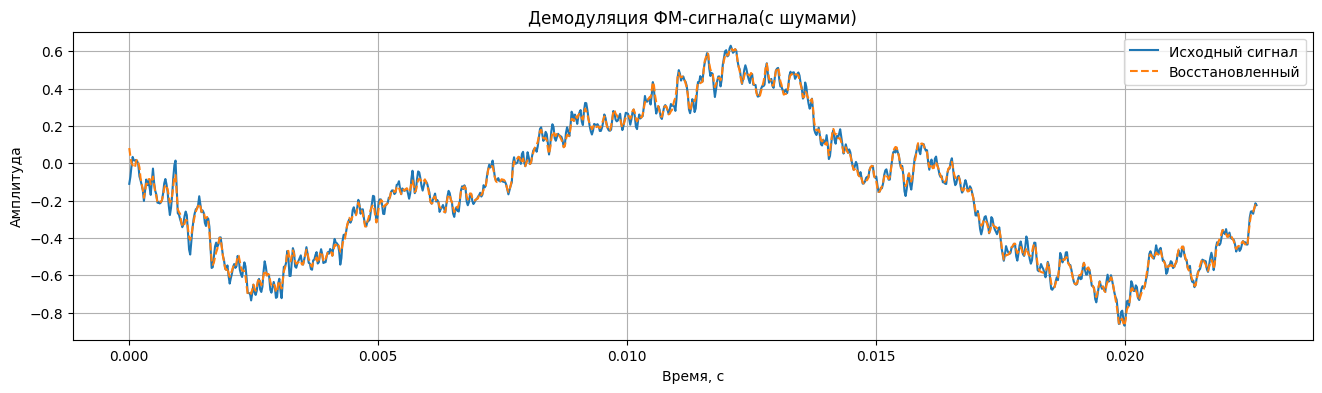

In [474]:
analytic = hilbert(s_pm_noisy)
instant_phase = np.unwrap(np.angle(analytic))
carrier_phase = 2 * np.pi * fc_high * t_audio
melody_restored2 = (instant_phase - carrier_phase) / beta_pm_audio

# error check
mse = np.mean((melody - melody_restored2)**2)
print(f'MSE: {mse:.6f}')

plt.figure(figsize=(16, 4))
plt.plot(t_audio[:1000], melody[:1000], label='Исходный сигнал')
plt.plot(t_audio[:1000], melody_restored[:1000], '--', label='Восстановленный')
plt.legend()
plt.title('Демодуляция ФМ-сигнала(с шумами)')
plt.xlabel('Время, с')
plt.ylabel('Амплитуда')
plt.grid(True)
plt.show()

Тест звука:

In [475]:
display(Audio(melody, rate=fs_audio))

display(Audio(melody_restored, rate=fs_audio))

display(Audio(melody_restored2, rate=fs_audio))

**Вопросы:**
* Изменилось ли качество звука?
* Зафиксируйте $\beta=2$. Попробуйте поменять амплитуду шума. При каких значениях амплитуды вы слышите заметную разницу с оригиналом?
* Зафиксируйте амплитуду шума равную 0,1. Попробуйте поменять $\beta$. Как субъективная величина искажений зависит от $\beta$?

1. Качество звука изменилось незначительно.
2. При фиксированном beta заметные искажения начинают проявляться при амплитуде шума примерно 0.02–0.05.
3. При фиксированном уровне шума(0.1) увеличение индекса модуляции beta приводит к уменьшению искажений.

### 4.6. Сравнение спектров

Выберите значение амплитуды шума и величин $a_{AM}$ и $\beta$ так, чтобы искажения были заметны, но не велики. Постройте спектры исходного сигнала и сигналов, восстановлённых из зашумлённых АМ и ФМ-сигналов.

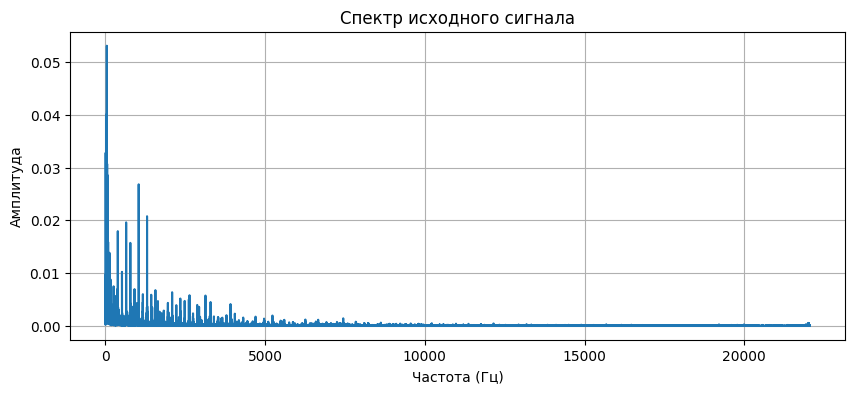

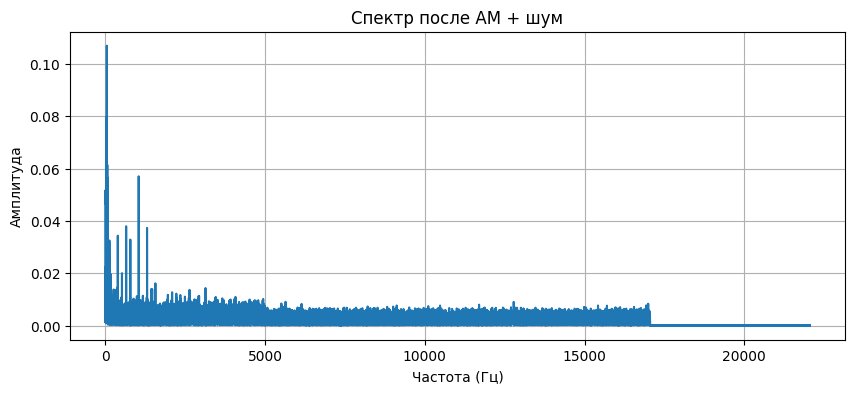

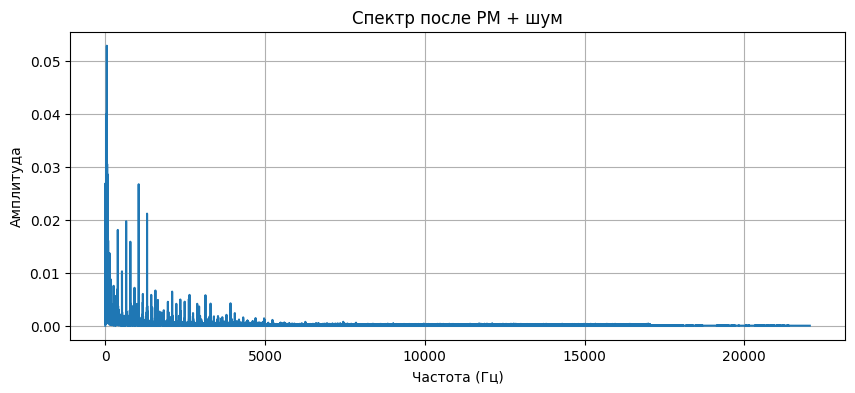

In [476]:
a_am = 0.1
beta_pm_audio = 2
noisy_level = 0.05

noise = noisy_level * np.random.randn(len(t_audio))

s_am_new_noisy = s_am_audio + noise
s_pm_new_noisy = s_pm_audio + noise

analytic_am = hilbert(s_am_new_noisy)
envelope_am = np.abs(analytic_am)
melody_restored_am = (envelope_am / Ac - 1) / a_am

analytic_pm = hilbert(s_pm_new_noisy)
instant_phase = np.unwrap(np.angle(analytic_pm))

carrier_phase = 2 * np.pi * fc_high * t_audio
phase_no_carrier = instant_phase - carrier_phase
phase_no_carrier -= np.mean(phase_no_carrier)

melody_restored_pm = phase_no_carrier / beta_pm_audio

def spectrum_plot(signal, fs, title):
    N = len(signal)
    X = np.fft.fft(signal)
    freq = np.fft.fftfreq(N, 1/fs)

    half = N // 2
    X_mag = 2 * np.abs(X[:half]) / N
    freq = freq[:half]

    plt.figure(figsize=(10,4))
    plt.plot(freq, X_mag)
    plt.xlabel('Частота (Гц)')
    plt.ylabel('Амплитуда')
    plt.title(title)
    plt.grid(True)
    plt.show()

spectrum_plot(melody, fs_audio, 'Спектр исходного сигнала')

spectrum_plot(melody_restored_am, fs_audio, 'Спектр после АМ + шум')

spectrum_plot(melody_restored_pm, fs_audio, 'Спектр после PM + шум')



**Вопрос:**
* Заметны ли визуально искажения спектров для случаев АМ и ФМ?

Для АМ- заметны.

Для ФМ- незначительно на больших частотах.

Постройте спектры АМ и ФМ сигналов. Зафиксируйте $\beta=2$, подберите $a_{AM}$ так, чтобы амплитуды гармоник в обоих случаях были сравнимы по величине.

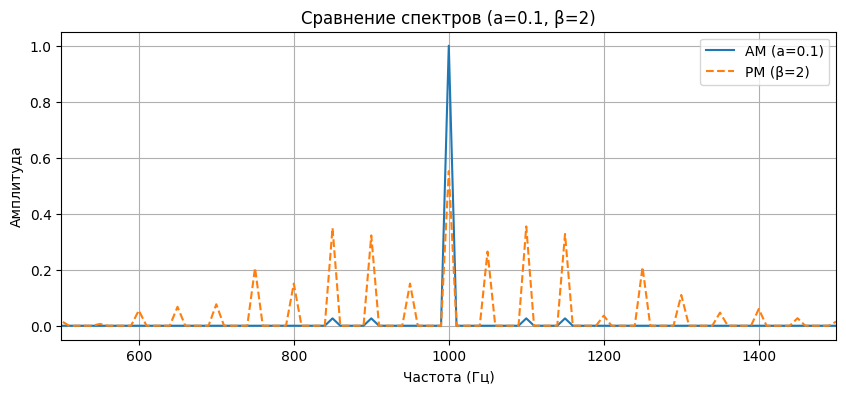

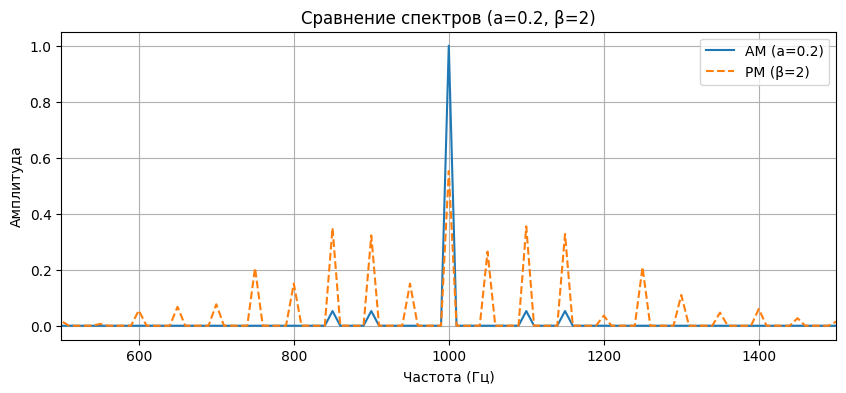

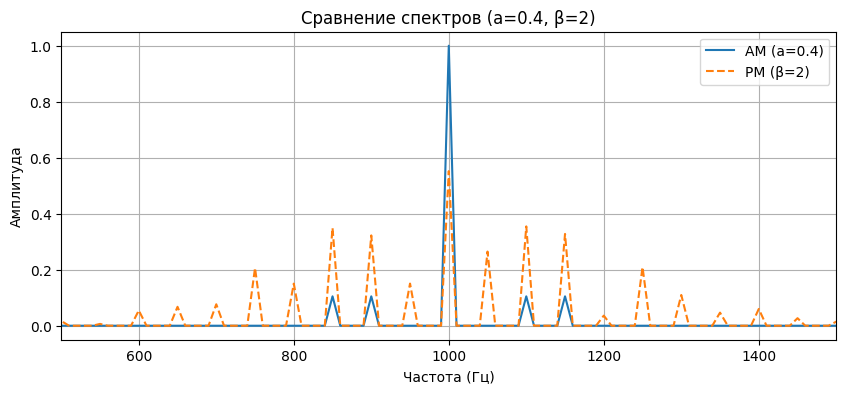

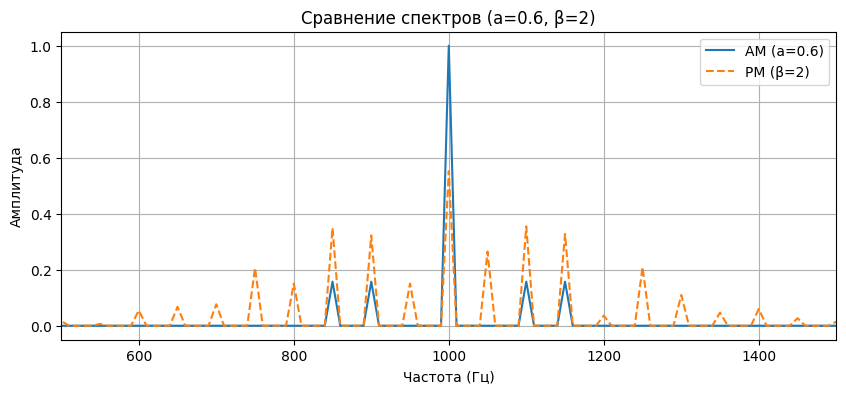

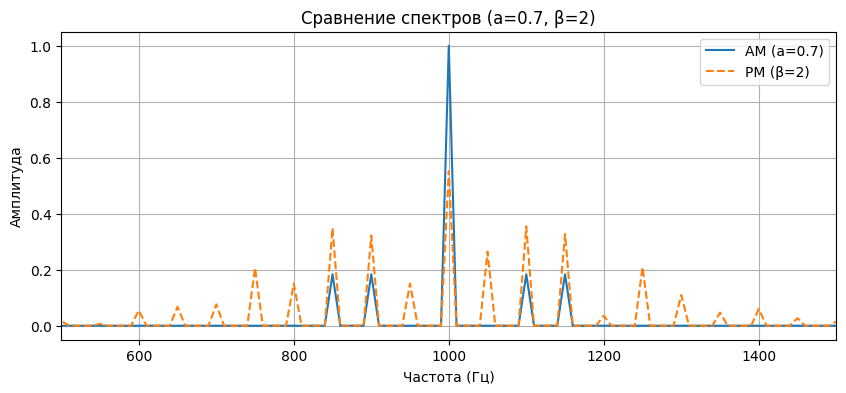

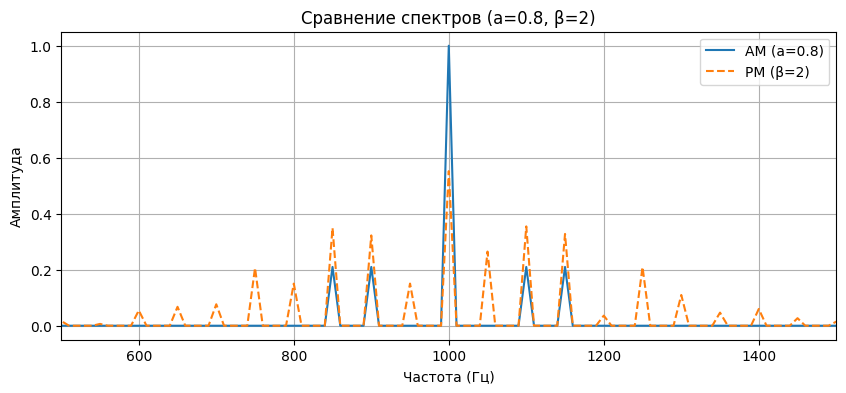

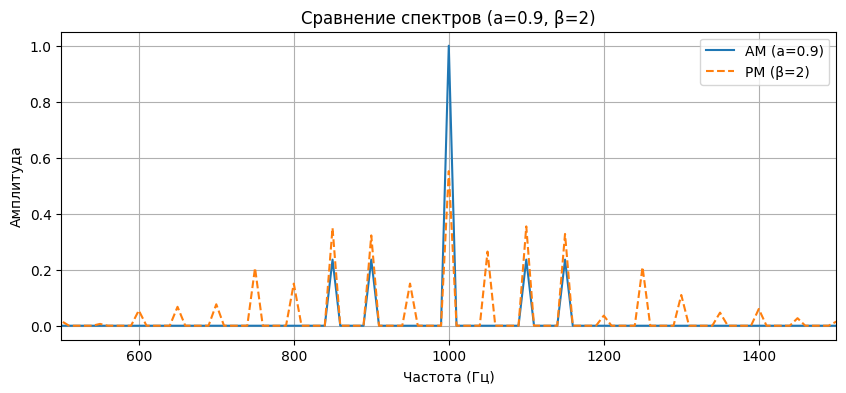

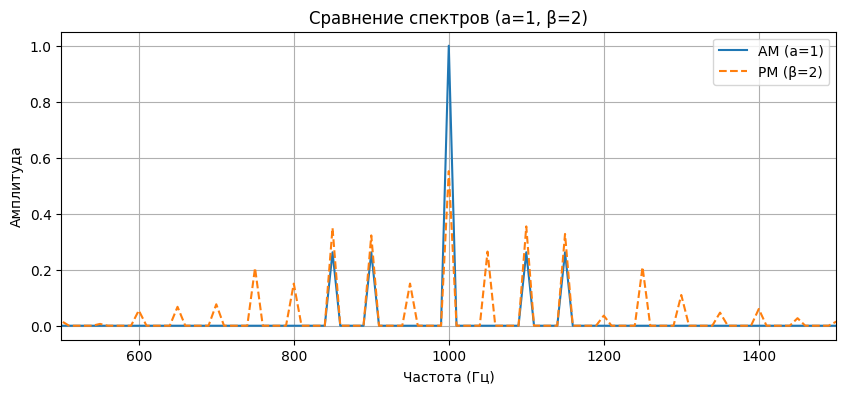

In [477]:
def compare_am_pm_spectra(a_values, beta, m_t, fc, t, fs):
    def spectrum(signal):
        N = len(signal)
        X = np.fft.fft(signal)
        freq = np.fft.fftfreq(N, 1/fs)

        half = N // 2
        X_mag = 2 * np.abs(X[:half]) / N
        freq = freq[:half]
        return freq, X_mag

    for a_am in a_values:
        s_am = (1 + a_am * m_t) * np.cos(2*np.pi*fc*t)
        s_pm = np.cos(2*np.pi*fc*t + beta * m_t)

        f_am, X_am = spectrum(s_am)
        f_pm, X_pm = spectrum(s_pm)

        plt.figure(figsize=(10,4))

        plt.plot(f_am, X_am, label=f'AM (a={a_am})')
        plt.plot(f_pm, X_pm, '--', label=f'PM (β={beta})')

        plt.xlim(fc-500, fc+500)
        plt.xlabel('Частота (Гц)')
        plt.ylabel('Амплитуда')
        plt.title(f'Сравнение спектров (a={a_am}, β={beta})')
        plt.legend()
        plt.grid(True)
        plt.show()
a_values = [0.1, 0.2, 0.4, 0.6, 0.7, 0.8, 0.9, 1]
beta = 2

compare_am_pm_spectra(a_values, beta, m_t, fc, t, fs)

**Вопрос:**
* При какой амплитуде шума в этом случае вы слышите заметные искажения АМ сигнала? А ФМ сигнала? Сделайте вывод.

Наиболее подходящий АМ-сигнал в диапазоне от 0.8 до 1.
При выбранных параметрах заметные искажения:

для АМ-сигнала начинают проявляться уже при амплитуде шума около 0.03–0.05
для ФМ-сигнала — при более высоких значениях, примерно 0.08–0.1